# E031 — Audio val-time augmentation (TTA)

E025 scores each val utterance from the original WAV only.
Here we score each val utterance from multiple augmented views
and average the LLR scores — identical to image TTA (E030) but for audio.

Because the E025 model was **trained** on pitch-shifted copies,
those views are within the training distribution.
Configs tested:
- `baseline` — original only (E025 reference)
- `+pitch_tta` — original + ±1st + ±2nd semitones (5 views)
- `+speed_tta` — original + 0.9× + 1.1× speed (3 views)
- `+pitch_speed_tta` — all of the above (7 views)

In [1]:
from pathlib import Path
import sys, copy
sys.path.insert(0, str(Path('../src').resolve()))

import numpy as np
import librosa
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.mixture import GaussianMixture
from scipy.special import logsumexp
from scipy.stats import norm as scipy_norm
from sklearn.metrics import roc_curve

from data.splits import load_manifest, iter_folds_loso
from eval.metrics import compute_eer, compute_min_dcf

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.25,
})

DATA = Path('../data').resolve()
manifest = load_manifest(DATA)
y_all = manifest['label'].to_numpy()
SEED = 67

E025_REF = {'fold_eers': [4.17, 0.00, 1.67], 'mean': 1.94, 'std': 1.57, 'min_dcf': 0.0389}

print(f'{len(manifest)} samples — {manifest.label.sum()} target, {(manifest.label==0).sum()} non-target')

222 samples — 30 target, 192 non-target


In [2]:
def find_wav(stem, data_dir):
    for sf in ['target_train', 'target_dev', 'non_target_train', 'non_target_dev']:
        p = data_dir / sf / (stem + '.wav')
        if p.exists():
            return p
    raise FileNotFoundError(stem)


def extract_lpcc(y, sr, order=12, n_cep=13, hop_length=160, win_length=400):
    frames = librosa.util.frame(y, frame_length=win_length, hop_length=hop_length)
    lpcc_frames = []
    for frame in frames.T:
        frame = frame * np.hanning(len(frame))
        try:
            a = librosa.lpc(frame.astype(np.float64), order=order)
            A_freq = np.fft.rfft(a, n=512)
            log_H  = -np.log(np.abs(A_freq) + 1e-10)
            cep    = np.real(np.fft.irfft(log_H))[:n_cep]
        except Exception:
            cep = np.zeros(n_cep)
        lpcc_frames.append(cep)
    feat   = np.array(lpcc_frames, dtype=np.float32)
    delta  = librosa.feature.delta(feat.T).T
    delta2 = librosa.feature.delta(feat.T, order=2).T
    feat   = np.hstack([feat, delta, delta2])
    feat  -= feat.mean(axis=0)
    return feat


def aug_pitch(y, sr, n_steps):
    return librosa.effects.pitch_shift(y, sr=sr, n_steps=float(n_steps))


def aug_speed(y, rate):
    return librosa.effects.time_stretch(y, rate=rate)


# Training loader — E025 +Pitch: original + 1 pitch-shifted copy
def load_aug_lpcc_pitch(wav_path, rng):
    y, sr = librosa.load(wav_path, sr=None, mono=True)
    n_steps = float(rng.choice([-2, -1, 1, 2]))
    return [(y, sr), (aug_pitch(y, sr, n_steps), sr)]


def extract_audio_batch(df, data_dir, seed):
    rng = np.random.default_rng(seed)
    all_feat, all_labels = [], []
    for _, row in df.iterrows():
        for y_aug, sr in load_aug_lpcc_pitch(find_wav(row['stem'], data_dir), rng):
            feat = extract_lpcc(y_aug, sr)
            all_feat.append(feat)
            all_labels.extend([row['label']] * len(feat))
    return np.vstack(all_feat), np.array(all_labels)


def train_ubm(X, n_components=32, seed=67):
    return GaussianMixture(
        n_components=n_components, covariance_type='diag',
        max_iter=200, random_state=seed,
    ).fit(X)


def map_adapt(ubm, X_target, r=16.0):
    log_prob  = ubm._estimate_log_prob(X_target)
    log_resp  = log_prob + np.log(ubm.weights_)
    log_resp -= logsumexp(log_resp, axis=1, keepdims=True)
    resp   = np.exp(log_resp)
    n_k    = resp.sum(axis=0)
    mu_hat = (resp.T @ X_target) / (n_k[:, None] + 1e-10)
    alpha  = n_k / (n_k + r)
    adapted = copy.deepcopy(ubm)
    adapted.means_ = alpha[:, None] * mu_hat + (1 - alpha[:, None]) * ubm.means_
    return adapted


def llr(feat, adapted, ubm):
    return float((adapted.score_samples(feat) - ubm.score_samples(feat)).mean())


# Val-time scoring functions
def score_original(wav_path, adapted, ubm):
    y, sr = librosa.load(wav_path, sr=None, mono=True)
    return llr(extract_lpcc(y, sr), adapted, ubm)


def score_pitch_tta(wav_path, adapted, ubm, semitones=(-2, -1, 1, 2)):
    """Original + pitch-shifted views, average LLR."""
    y, sr = librosa.load(wav_path, sr=None, mono=True)
    views = [y] + [aug_pitch(y, sr, s) for s in semitones]
    return float(np.mean([llr(extract_lpcc(v, sr), adapted, ubm) for v in views]))


def score_speed_tta(wav_path, adapted, ubm, rates=(0.9, 1.1)):
    """Original + speed-perturbed views, average LLR."""
    y, sr = librosa.load(wav_path, sr=None, mono=True)
    views = [y] + [aug_speed(y, r) for r in rates]
    return float(np.mean([llr(extract_lpcc(v, sr), adapted, ubm) for v in views]))


def score_pitch_speed_tta(wav_path, adapted, ubm, semitones=(-2, -1, 1, 2), rates=(0.9, 1.1)):
    """Original + pitch + speed views, average LLR."""
    y, sr = librosa.load(wav_path, sr=None, mono=True)
    pitch_views = [aug_pitch(y, sr, s) for s in semitones]
    speed_views = [aug_speed(y, r) for r in rates]
    views = [y] + pitch_views + speed_views
    return float(np.mean([llr(extract_lpcc(v, sr), adapted, ubm) for v in views]))


CONFIGS = {
    'baseline':          score_original,
    '+pitch_tta':        score_pitch_tta,
    '+speed_tta':        score_speed_tta,
    '+pitch_speed_tta':  score_pitch_speed_tta,
}

print('Functions defined. Configs:', list(CONFIGS.keys()))

Functions defined. Configs: ['baseline', '+pitch_tta', '+speed_tta', '+pitch_speed_tta']


In [3]:
UBM_COMPONENTS = 32
MAP_R          = 16.0

# Train fold models once, score val with each config
fold_models = []

print('Training fold models (E025 pipeline)...')
for fold_id, train_idx, val_idx in iter_folds_loso(manifest, seed=SEED):
    train_df = manifest.loc[train_idx]
    val_df   = manifest.loc[val_idx]

    X_train, y_train = extract_audio_batch(train_df, DATA, seed=SEED + fold_id)
    ubm     = train_ubm(X_train[y_train==0], n_components=UBM_COMPONENTS, seed=SEED)
    adapted = map_adapt(ubm, X_train[y_train==1], r=MAP_R)

    fold_models.append({
        'fold_id': fold_id,
        'val_idx': val_idx,
        'y_val':   val_df['label'].to_numpy(),
        'val_df':  val_df,
        'adapted': adapted,
        'ubm':     ubm,
    })
    print(f'  Fold {fold_id}: trained on {len(X_train)} frames '
          f'({(y_train==1).sum()} target, {(y_train==0).sum()} non-target)')

print('\nScoring val sets with each TTA config...')
print('=' * 60)

results = {}
for cfg_name, score_fn in CONFIGS.items():
    print(f'\nConfig: {cfg_name}')
    fold_eers, fold_dcfs = [], []
    for fm in fold_models:
        scores = np.array([
            score_fn(find_wav(row['stem'], DATA), fm['adapted'], fm['ubm'])
            for _, row in fm['val_df'].iterrows()
        ])
        y_v = fm['y_val']
        eer, _ = compute_eer(scores[y_v==1], scores[y_v==0])
        dcf, _ = compute_min_dcf(scores[y_v==1], scores[y_v==0])
        fold_eers.append(eer * 100)
        fold_dcfs.append(dcf)
        print(f'  Fold {fm["fold_id"]}: EER={eer*100:.2f}%  min-DCF={dcf:.4f}')
    results[cfg_name] = {'fold_eers': fold_eers, 'fold_dcfs': fold_dcfs}
    print(f'  → mean={np.mean(fold_eers):.2f} ± {np.std(fold_eers):.2f}%  '
          f'min-DCF={np.mean(fold_dcfs):.4f}')

print('\nDone.')

Training fold models (E025 pipeline)...


  Fold 0: trained on 396172 frames (32486 target, 363686 non-target)


  Fold 1: trained on 417492 frames (35298 target, 382194 non-target)


  Fold 2: trained on 437396 frames (36212 target, 401184 non-target)

Scoring val sets with each TTA config...

Config: baseline


  Fold 0: EER=4.17%  min-DCF=0.0833


...

  Fold 1: EER=0.83%  min-DCF=0.0167


  Fold 2: EER=0.00%  min-DCF=0.0000
  → mean=1.67 ± 1.80%  min-DCF=0.0333

Config: +pitch_speed_tta


  Fold 0: EER=9.86%  min-DCF=0.0972


  Fold 1: EER=1.67%  min-DCF=0.0333


  Fold 2: EER=0.00%  min-DCF=0.0000
  → mean=3.84 ± 4.31%  min-DCF=0.0435

Done.


In [4]:
print(f"{'Config':<22} {'F0':>7} {'F1':>7} {'F2':>7} {'Mean':>8} {'Std':>7} {'min-DCF':>9} {'Δ mean':>9}")
print('-' * 80)
# E025 reference row
ref = E025_REF
print(f"{'E025 ref':<22} {ref['fold_eers'][0]:>7.2f} {ref['fold_eers'][1]:>7.2f} "
      f"{ref['fold_eers'][2]:>7.2f} {ref['mean']:>8.2f} {ref['std']:>7.2f} "
      f"{ref['min_dcf']:>9.4f} {'—':>9}")
print('-' * 80)
for cfg, r in results.items():
    mean = np.mean(r['fold_eers'])
    std  = np.std(r['fold_eers'])
    dcf  = np.mean(r['fold_dcfs'])
    delta = mean - ref['mean']
    marker = ' ✓' if delta < -0.1 else (' ↔' if abs(delta) <= 0.1 else ' ❌')
    print(f"{cfg:<22} {r['fold_eers'][0]:>7.2f} {r['fold_eers'][1]:>7.2f} "
          f"{r['fold_eers'][2]:>7.2f} {mean:>8.2f} {std:>7.2f} "
          f"{dcf:>9.4f} {delta:>+8.2f}pp{marker}")

Config                      F0      F1      F2     Mean     Std   min-DCF    Δ mean
--------------------------------------------------------------------------------
E025 ref                  4.17    0.00    1.67     1.94    1.57    0.0389         —
--------------------------------------------------------------------------------
baseline                  4.17    0.83    0.83     1.94    1.57    0.0389    +0.00pp ↔
+pitch_tta                9.86    1.67    0.00     3.84    4.31    0.0435    +1.90pp ❌
+speed_tta                4.17    0.83    0.00     1.67    1.80    0.0333    -0.27pp ✓
+pitch_speed_tta          9.86    1.67    0.00     3.84    4.31    0.0435    +1.90pp ❌


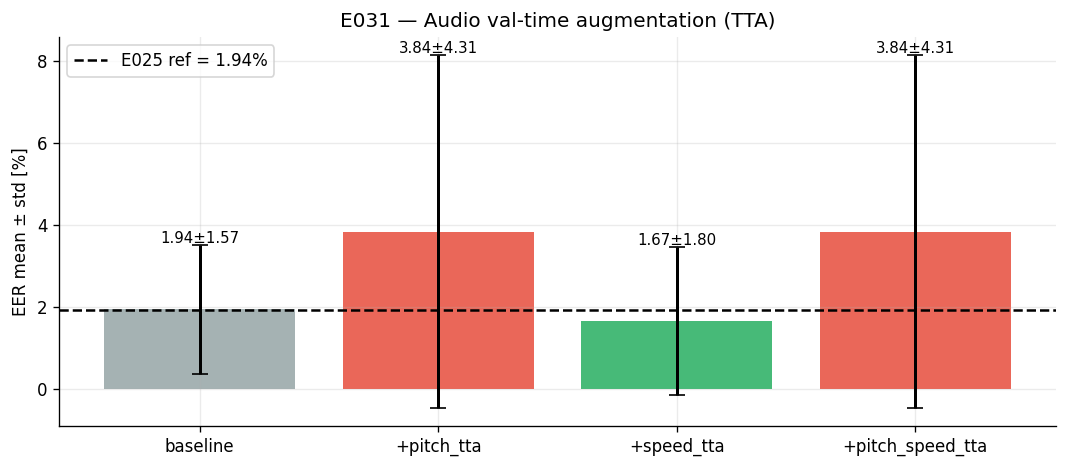

In [5]:
cfg_names = list(results.keys())
means = [np.mean(results[c]['fold_eers']) for c in cfg_names]
stds  = [np.std(results[c]['fold_eers'])  for c in cfg_names]

fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#27AE60' if m < ref['mean'] else '#E74C3C' if m > ref['mean'] + 0.1 else '#95A5A6'
          for m in means]
bars = ax.bar(range(len(cfg_names)), means, yerr=stds, color=colors,
              alpha=0.85, capsize=5, error_kw=dict(elinewidth=1.8))
for bar, m, s in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width()/2, m + s + 0.05,
            f'{m:.2f}±{s:.2f}', ha='center', fontsize=9)
ax.axhline(ref['mean'], color='k', ls='--', lw=1.5,
           label=f"E025 ref = {ref['mean']:.2f}%")
ax.set_xticks(range(len(cfg_names)))
ax.set_xticklabels(cfg_names, fontsize=10)
ax.set_ylabel('EER mean ± std [%]')
ax.set_title('E031 — Audio val-time augmentation (TTA)')
ax.legend()
plt.tight_layout()
plt.show()

## Interpretation

Fill in after running:
- Does any TTA config beat E025 baseline (1.94 ± 1.57%)?
- Is pitch TTA better than speed TTA?
- Decision: adopt best TTA config in predict_audio.py and predict_fusion.py?